In [1]:
!pip install -q "transformers==4.38.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 73.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [3]:
import torch
print("CUDA:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
from google.colab import drive
drive.mount('/content/drive')

CUDA: True | Tesla T4


MessageError: Error: credential propagation was unsuccessful

In [ ]:
import sys, torch
sys.path.insert(0, '/content/drive/MyDrive/mrabert_run')
from mRNAbert_model.bert_layers import BertForMaskedLM
from mRNAbert_model.configuration_bert import BertConfig
from transformers import AutoTokenizer

MODEL = '/content/drive/MyDrive/mrabert_run/mRNAbert_model'
config    = BertConfig.from_pretrained(MODEL)
config.attention_probs_dropout_prob = 0.1
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model     = BertForMaskedLM.from_pretrained(MODEL, config=config)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device).eval()
print("loaded:", model.__class__.__name__,
      "| params:", f"{sum(p.numel() for p in model.parameters()):,}",
      "| device:", device)

You are using a model of type bert to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


loaded: BertForMaskedLM | params: 113,981,258 | device: cuda


In [ ]:
import torch

def format_cds(cds_string):
    cds = cds_string.upper().replace('U', 'T')
    if len(cds) % 3 != 0:
        raise ValueError(f"CDS length {len(cds)} is not divisible by 3. Check the sequence.")
    codons = [cds[i:i+3] for i in range(0, len(cds), 3)]
    return ' '.join(codons)

def compute_llr(cds_string, codon_index, wildtype_codon, mutant_codon):
    formatted = format_cds(cds_string)
    tokens = tokenizer(formatted, return_tensors='pt')
    input_ids = tokens['input_ids'].clone().to(model.device)        # <-- НА GPU

    token_position = codon_index + 1
    actual_token = tokenizer.convert_ids_to_tokens(
        [input_ids[0, token_position].item()])[0]
    if actual_token != wildtype_codon:
        raise ValueError(f"Mismatch at position {codon_index}: "
                         f"expected '{wildtype_codon}' but found '{actual_token}'. "
                         f"Check the codon_index.")

    input_ids[0, token_position] = tokenizer.mask_token_id

    with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
      outputs = model(input_ids)

    logits = outputs.logits[0, token_position, :]
    log_probs = torch.log_softmax(logits, dim=-1)

    wt_id  = tokenizer.convert_tokens_to_ids(wildtype_codon)
    mut_id = tokenizer.convert_tokens_to_ids(mutant_codon)
    log_p_wt  = log_probs[wt_id].item()
    log_p_mut = log_probs[mut_id].item()

    llr = log_p_mut - log_p_wt
    return llr, log_p_wt, log_p_mut

In [ ]:
def compute_llr_windowed (cds_string, codon_index, wildtype_codon, mutant_codon, window_size = 1022):
    """
    Same as compute_llr() but handles sequences longer than the model's limit of 1022 codons.

    Strategy: extract a window of 'window_size' codons centered on the target codon_index, then run compute_llr on that window.

    The mutation's codon_index within the window is recalculated automatically.
    """

    #Line1: parse the full CDS into a list of codons
    cds = cds_string.upper().replace('U', 'T')
    if len(cds) % 3 != 0:
        raise ValueError(f"CDS length {len(cds)} not divisible by 3")

    all_codons = [cds[i:i+3] for i in range (0, len(cds), 3)]
    total_codons = len(all_codons)

    print(f"Total codons number in seq: {total_codons}")
    print(f"Model maximum: {window_size}")
    print(f"Target codon index: {codon_index}")

    #Line2: if the seq fits in the model, than no window needed
    if total_codons <= window_size:
        print(f"Sequence fits in model -> no window needed")
        return compute_llr(cds_string, codon_index, wildtype_codon, mutant_codon)

    #Line3: Seq is too long -> extract a centered window (center the window on the target codon!)
    half = window_size //2 # that means 511 codons on each side

    #Line4: calculate the window start (center on the target codon)
    window_start = codon_index - half # good option when the target codon is somewhere in the middle of the gene
    window_start = max(0, window_start) # when the target codon at the beginning, we can get the negative score that will mean absolutely different thing that i want to do (read backwards from the end) -> use max function -> window starts at the beginning, not a negative position

    #Line5: calculate the window end
    window_end = window_start + window_size

    #Line6: if the window goes past the seq, shift window left
    if window_end > total_codons:
        window_end = total_codons
        window_start = window_end - window_size
        window_start = max(0, window_start)

    #Line7: extract the window as a codon list, then rejoin into a CDS string
    window_codons = all_codons[window_start:window_end]
    window_cds = ''.join(window_codons)

    #Line8: recalculate the codon index within the window (it starts at window_start, not 0)
    local_codon_index = codon_index - window_start

    #Line9: print eindow info for verification
    print(f"\nWindow: codons {window_start} → {window_end}  ({window_end - window_start} codons)")
    print(f"Target codon position in window: {local_codon_index}")
    print(f"Codons before target: {local_codon_index}")
    print(f"Codons after target:  {window_end - window_start - local_codon_index - 1}")

    # Line10: Run the standard LLR on the window
    return compute_llr(window_cds, local_codon_index, wildtype_codon, mutant_codon)


In [ ]:
import json, pandas as pd
# data
mut = pd.read_parquet("/content/drive/MyDrive/mrabert_run/synmic_mutations_verified.parquet")
mut = mut[mut["verify"] == "ok"].reset_index(drop=True)
cds_by_transcript = json.load(open("/content/drive/MyDrive/mrabert_run/cds_by_transcript.json"))
print("mutations to score:", len(mut))
# assemble the 4 arguments from a table row
def build_args(row):
    cds   = cds_by_transcript[row["Transcript ID"]]
    ci    = int(row["codon_idx"]) - 1
    start = ci * 3
    wt    = cds[start:start+3]
    mt    = wt[:row["pos_in_codon"]] + row["alt"] + wt[row["pos_in_codon"]+1:]
    return cds, ci, wt, mt
# ANCHOR KRAS c.36T>C: expect ≈ -2.43
r = mut[(mut["Gene Name"] == "KRAS") & (mut["Mutation nt"] == "c.36T>C")].iloc[0]
cds, ci, wt, mt = build_args(r)
print("wt:", wt, "| mut:", mt, "| codon_index:", ci)
llr, lpw, lpm = compute_llr_windowed(cds, ci, wt, mt)
print("KRAS c.36T>C LLR =", round(llr, 4), " (expect ≈ -2.43)")

mutations to score: 496422
wt: GGT | mut: GGC | codon_index: 11
Total codons number in seq: 189
Model maximum: 1022
Target codon index: 11
Sequence fits in model -> no window needed
KRAS c.36T>C LLR = -2.4368  (expect ≈ -2.43)


The anchor matched exactly

This means:
*   the model on the GPU computes identically to the local version,
*   bypassing Triton via the dropout flag didn't break anything,
*   argument assembly, coordinates, window — all correct,
*   496,422 mutations loaded and ready.

In [ ]:
#from mRNAbert_model.configuration_bert import BertConfig
#cfg = BertConfig.from_pretrained('/content/drive/MyDrive/mrabert_run/mRNAbert_model')
#print([k for k in vars(cfg) if 'attn' in k.lower() or 'flash' in k.lower() or 'triton' in k.lower()])

In [ ]:
#import re
#path = '/content/drive/MyDrive/mrabert_run/mRNAbert_model/bert_layers.py'
#src = open(path).read()

# показать строки, где упоминается flash / triton / attention выбор
#for i, line in enumerate(src.split('\n')):
#   if re.search(r'flash|triton|trans_b|attn_impl|unpad|FlashAttn|self\.attention', line, re.I):
#       print(i, line)

key lines:
line 159: if self.p_dropout or flash_attn_qkvpacked_func is None: → if p_dropout (attention dropout) is nonzero, the model goes down the ordinary PyTorch attention path and doesn't touch Triton. lines 172, 175: "Triton implementation only supports 0 attention dropout" — i.e. Triton kicks in only when dropout is exactly 0.

So the trick is simple: set attention-dropout slightly above zero at load time — and the model will route itself to the PyTorch branch, bypassing the broken Triton kernel. At inference with model.eval() dropout is disabled anyway (doesn't "spoil" anything), here it works purely as a path switch.

In [ ]:
# speed benchmark on 200 random mutations
import time
sample = mut.sample(200, random_state=0).reset_index(drop=True)
def score_row(row):
    try:
        cds, ci, wt, mt = build_args(row)
        return compute_llr_windowed(cds, ci, wt, mt)
    except Exception:
        return None
import sys, os, contextlib
with open(os.devnull,'w') as dn, contextlib.redirect_stdout(dn):   # silence the print from the function
    t0 = time.perf_counter()
    res = [score_row(r) for _, r in sample.iterrows()]
    dt = time.perf_counter() - t0
ok = [x for x in res if x is not None]
per = dt/len(sample)
print(f"{per*1000:.0f} ms/mutation | failures: {len(res)-len(ok)}/200")
print(f"for 496422 -> {per*len(mut)/3600:.1f} hours")

44 ms/mutation | failures: 0/200
for 496422 -> 6.0 hours


autocast worked

both results:
- Anchor: KRAS c.36T>C LLR = -2.4368 (was −2.4307 on fp32).
- Shift = 0.0061 — within the normal range for fp16-autocast (expected ±0.02, got four times smaller). Numerically the model computes the same thing, just with slight fp16 noise in the heavy matmuls. Anchor accepted. Speed: 35 ms/mutation | failures: 0/200 → for 496422 = 4.8 hours (was 71 ms / 9.8 h).

Exactly ×2 speedup, 0 failures. autocast ran cleanly.

In [ ]:
import pandas as pd
done = pd.read_parquet("/content/drive/MyDrive/mrabert_run/llr_results.parquet")
print("already counted:", len(done))

already counted: 496422


In [ ]:
import os, json, time, contextlib
import pandas as pd
OUT = "/content/drive/MyDrive/mrabert_run/llr_results.parquet"
CHECKPOINT_EVERY = 2000
# resume: if the file already exists, continue from where it broke off
if os.path.exists(OUT):
    done = pd.read_parquet(OUT)
    done_ids = set(done["Mutation ID"])
    print(f"checkpoint found: already computed {len(done_ids)}")
else:
    done = pd.DataFrame(columns=["Mutation ID","llr","log_p_wt","log_p_mut"])
    done_ids = set()
    print("no checkpoint, starting from zero")
todo = mut[~mut["Mutation ID"].isin(done_ids)].reset_index(drop=True)
print(f"remaining to compute: {len(todo)} of {len(mut)}")
# main loop
buffer = []
devnull = open(os.devnull, "w")
t0 = time.perf_counter()
for i, row in todo.iterrows():
    try:
        cds, ci, wt, mt = build_args(row)
        with contextlib.redirect_stdout(devnull):
            llr, lpw, lpm = compute_llr_windowed(cds, ci, wt, mt)
    except Exception:
        llr = lpw = lpm = None
    buffer.append({"Mutation ID": row["Mutation ID"],
                   "llr": llr, "log_p_wt": lpw, "log_p_mut": lpm})
    # save checkpoint
    if (i + 1) % CHECKPOINT_EVERY == 0:
        done = pd.concat([done, pd.DataFrame(buffer)], ignore_index=True)
        done.to_parquet(OUT, index=False)
        buffer = []
        el = time.perf_counter() - t0
        speed = (i + 1) / el
        eta = (len(todo) - (i + 1)) / speed / 3600
        print(f"[{i+1}/{len(todo)}] saved | {speed:.1f} mut/sec | ETA {eta:.1f} h")
# final flush of the remainder
if buffer:
    done = pd.concat([done, pd.DataFrame(buffer)], ignore_index=True)
    done.to_parquet(OUT, index=False)
print(f"DONE: total {len(done)} mutations saved to {OUT}")

checkpoint found: already computed 496422
remaining to compute: 0 of 496422
DONE: total 496422 mutations saved to /content/drive/MyDrive/mrabert_run/llr_results.parquet


**Spearman correlation: does the LLR predict the SynMICdb score?**

The first statistical test asks whether there is a monotonic relationship between the model's prediction (pred = −LLR) and the actual SynMICdb score. If mRNABERT captures functional relevance, high pred should go hand in hand with high score.

**Why Spearman and not Pearson.**

Spearman works on ranks rather than raw values, so it detects any monotonic relationship (not just a linear one) and is robust to outliers and skewed distributions.

This matters here: the LLR has heavy tails (−16 to +11) and the SynMICdb score has its own distribution, so a rank-based coefficient is more appropriate than Pearson.


*Result.* Across the full database (n ≈ 482,000), the directional predictor correlates with the SynMICdb score at ρ(−LLR, score) = +0.1218 (p ≈ 0, 95% CI [0.119, 0.125]), while the magnitude-only predictor reaches only ρ(|LLR|, score) = +0.0479. The correlation is weak, but at this sample size it is unambiguous (p ≈ 0). Two things carry the interpretation: the effect is positive in the predicted direction (variants the model finds contextually surprising tend to be the ones SynMICdb flags), and the directional predictor outperforms the magnitude-only one by roughly x2.5, meaning the model encodes the direction of the effect, not merely that a codon changed.

first 5 steps is the preparation


In [ ]:
# TEST A — Spearman correlation: does LLR predict the magnitude of the SynMICdb score?
import pandas as pd
import numpy as np
from scipy.stats import spearmanr  # pandas for tables, numpy for math, spearmanr from scipy — the test itself.
# 1. Load the two files
llr = pd.read_parquet("/content/drive/MyDrive/mrabert_run/llr_results.parquet")  # mRNABERT results: Mutation ID + llr
m   = pd.read_parquet("/content/drive/MyDrive/mrabert_run/synmic_mutations_verified.parquet")  # mutation table: score, labels, confounders
# 2. Only verified mutations
m_ok = m[m["verify"] == "ok"].copy()  # keep only verified mutations (496,422). Invalid transcripts were already filtered out at the scoring stage.
# 3. Join: attach llr to each mutation by the Mutation ID key
df = m_ok.merge(llr[["Mutation ID", "llr", "log_p_wt", "log_p_mut"]],
                on="Mutation ID", how="left")  # attach the llr column to each mutation by the Mutation ID key. After the join still 496,422 rows → the key is unique, nothing got duplicated.
# 4. Predictors under the fixed convention
df["pred"]     = -df["llr"]       # MAIN: -LLR (the more negative the LLR -> the more significant the mutation) # create the predictor column. Minus, because significance corresponds to a negative LLR.
df["pred_abs"] = df["llr"].abs()  # ALTERNATIVE: |LLR| (magnitude of deviation in either direction)
#5. For Test A take mutations that have BOTH llr AND score
d = df[df["llr"].notna() & df["has_score"]].copy()  # double filter: llr is not empty (notna) AND a score exists (has_score). & — elementwise "AND" for boolean masks (in pandas it's &, not and).
print("mutations in Test A:", len(d))
# 6. Main predictor: correlation of -LLR with score
rho, p = spearmanr(d["pred"], d["SynMICdb Score"])  # returns a tuple (rho, p): the rank correlation coefficient and the p-value. Computes the ranks of both variables and the Pearson correlation between the ranks.
print(f"MAIN     rho(-LLR, score)  = {rho:+.4f}   p = {p:.2e}")
# 7. Alternative: correlation of |LLR| with score
rho2, p2 = spearmanr(d["pred_abs"], d["SynMICdb Score"])
print(f"ALT.     rho(|LLR|, score) = {rho2:+.4f}   p = {p2:.2e}")
# 8. 95% confidence interval for the main rho (Fisher transform)
n = len(d)
z = np.arctanh(rho)  # arctanh = Fisher z-transform
se = 1 / np.sqrt(n - 3)  # standard error of z
lo, hi = np.tanh(z - 1.96*se), np.tanh(z + 1.96*se)  # np.arctanh(rho) — Fisher transform (turns rho into a normally-distributed quantity so a confidence interval can be built). se = 1/sqrt(n-3) — standard error. ±1.96·se — 95% bounds. np.tanh(...) — inverse transform back to the correlation scale.
print(f"95% CI for the main rho: [{lo:+.4f}, {hi:+.4f}]")

mutations in Test A: 483896
MAIN     rho(-LLR, score)  = +0.1218   p = 0.00e+00
ALT.     rho(|LLR|, score) = +0.0479   p = 7.06e-244
95% CI for the main rho: [+0.1190, +0.1246]


Results:
- main metric +0.1218 -> weak positive relationship
- the alternative variant is even weaker

**rho = 0.12** — this is a weak correlation.

- On the effect-size scale: 0.1 = weak, 0.3 = moderate, 0.5 = strong.
That is, mRNABERT LLR carries a real but small signal about the functional significance of synonymous mutations.

**But three things make this result defensible rather than a failure:**
- The signal is real, not random. p ≈ 0 and a narrow CI [0.119, 0.125] — on a sample of 484k, a correlation of 0.12 is rock-solidly distinguishable from zero. This isn't "noise that could have come up by chance." The effect is small, but it's definitely there.
- The directional hypothesis won. −LLR (0.122) is x2.5 stronger than |LLR| (0.048). This means the sign of LLR matters, not the magnitude: the model doesn't just sense that the mutation changes something, it correctly identifies the direction (negative LLR → deleterious).
- Scaling confirmed the signal. On 303 mutations it was rho ≈ ±0.14–0.21. Now on 484k — rho 0.12, p≈0. The effect held up under a x1600 increase in sample size.

**Why a weak correlation is normal and expected**

The SynMICdb score is by construction dominated by mutation frequency and mutational load (this is clear from the Sharma 2019 paper itself — the score is built mainly from signature-normalized frequency and mutation load). mRNABERT doesn't see these things, it looks only at the RNA sequence. So it physically cannot explain most of the variance in the score. What's surprising isn't that rho is small, but that it's significantly greater than zero at all, meaning there's a component in the score tied to the "language of RNA," and the model catches it.

And here's the key question: **is this signal over and above codon frequency, or is it just a re-reflection of that same frequency?**

If LLR correlates with the score only because both depend on codon usage — then mRNABERT has no independent contribution.

If the signal survives controlling for frequency, it does. That's the partial correlation.

**TEST B — AUROC / AUPRC: does LLR distinguish significant mutations from insignificant ones?**

Test A asked "does LLR correlate with the continuous score." Test B asks something different: "if split mutations into significant (top 10% / top 1% by SynMICdb) and the rest, can LLR tell them apart?" This is binary classification, and the metric here is not correlation but AUROC and AUPRC.

**What AUROC is**

Take a random significant mutation and a random insignificant one. AUROC = the probability that the significant one has a higher pred.
- 0.5 = the model doesn't distinguish (a coin flip),
- 1.0 = perfect,
- 0.6 = weak-to-moderate. The metric is robust to class imbalance.

**What AUPRC is and why it's critical here.**

top 1% is only 3,353 mutations out of ~480k, i.e. the classes are heavily imbalanced (significant <1%). Under such a skew AUROC can look decent but be misleading. AUPRC (precision-recall) more honestly shows how well we catch the rare positive class.

The AUPRC baseline = the proportion of positives (for top 1% this is ~0.007); anything above it is the model's added value.

In [ ]:
# TEST B — AUROC / AUPRC: does LLR distinguish significant mutations (top10 / top1)?

from sklearn.metrics import roc_auc_score, average_precision_score  # import two metrics from scikit-learn: AUROC and AUPRC (average precision = area under the PR curve)

# d — the same table as in Test A (join + pred + pred_abs already built).
# For Test B take mutations with a valid llr AND a score present (only then are the top10/top1 labels defined):

d = df[df["llr"].notna() & df["has_score"]].copy()  # filter: keep mutations where llr is valid (notna) AND a score exists (has_score). Without the second condition the top10/top1 labels contain NA → astype(int) fails with "cannot convert NA to integer" (the very error I hit and fixed).
print("mutations in Test B:", len(d))
# iterate over both significance labels
for label in ["top10", "top1"]:  # outer loop over the two definitions of a "significant" mutation (top 10% and top 1% by SynMICdb).
    y = d[label].astype(int)  # binary label: 1 = significant mutation, 0 = not
    base = y.mean() # proportion of positives = the AUPRC baseline: if the predictor is useless, AUPRC will be roughly equal to this proportion.
    print(f"\n=== label {label}: positives {int(y.sum())} ({base*100:.2f}%) ===")
    # iterate over both predictors
    for name, col in [("-LLR", "pred"), ("|LLR|", "pred_abs")]:
        auroc = roc_auc_score(y, d[col])  # area under the ROC curve # AUROC: probability that a random significant mutation has a higher pred than a random insignificant one. 0.5 = coin flip.
        auprc = average_precision_score(y, d[col])    # area under the precision-recall curve # AUPRC: how well the predictor pulls out the rare positive class.
        print(f"  {name:6s}: AUROC={auroc:.4f} | AUPRC={auprc:.4f} "
              f"(baseline {base:.4f}, lift x{auprc/base:.2f})")  # lift: how many times higher AUPRC is than the baseline (i.e. how much better LLR-based selection is than random).

mutations in Test B: 483896

=== label top10: positives 43033 (8.89%) ===
  -LLR  : AUROC=0.5471 | AUPRC=0.1059 (baseline 0.0889, lift x1.19)
  |LLR| : AUROC=0.5105 | AUPRC=0.0995 (baseline 0.0889, lift x1.12)

=== label top1: positives 3353 (0.69%) ===
  -LLR  : AUROC=0.5324 | AUPRC=0.0081 (baseline 0.0069, lift x1.17)
  |LLR| : AUROC=0.4985 | AUPRC=0.0076 (baseline 0.0069, lift x1.10)


- AUROC 0.53–0.55 — this is very weak discrimination. Ideal = 1.0, coin flip = 0.5. So as a binary "significant / not" classifier, LLR barely works at all.

- **important:** for |LLR| on top1, AUROC = 0.499, this is literally the level of random guessing. That is, the magnitude of LLR doesn't distinguish the most significant mutations at all. The directional −LLR, however, holds at 0.53, again confirming: the sign carries signal, the magnitude almost none. This is consistent with Test A and reinforces one and the same conclusion.

- **AUPRC and lift:** on top10, −LLR gives AUPRC 0.106 against a baseline of 0.089 -> lift ×1.19. This means: if you select candidates by LLR, the top will contain ~1.19× more truly significant ones than random selection would. Weak, but > 1 — i.e. not zero usefulness.

**How this fits with Test A and what it means**
 - no contradiction with Test A:
*  *Test A (rho 0.12, p≈0):* across the whole score range there's a weak but rock-solidly significant monotonic relationship. LLR senses direction.
*  *Test B (AUROC 0.53):* but drawing a sharp "significant/not" boundary by LLR is almost impossible, for binary filtering it's too weak.

**Conclusion:**

mRNABERT LLR is a weak ranking signal, not a classifier. It's good enough to say "on average, over a large sample, mutations with a more negative LLR are slightly more often functionally significant," but not good enough to decide "this one is deleterious" from a single mutation.

The main question ahead: even these weak 0.12 / 0.55 — are they mRNABERT's own contribution, or just a shadow of codon frequency (which the model learned and which itself correlates with the score)?
-> This is what **partial correlation** answers.

**PART 1 — Partial correlation on the available confounders**

What control for (7 confounders, all ~100% filled):
- Signature-normalized Frequency — the mutation's frequency in tumors (the main component of the SynMICdb score)
- Average Mutation Load — mutational load
- CGC Gene — gene in the Cancer Gene Census (0/1)
- Conservation — evolutionary conservation of the position
- Structure Change Score (remuRNA) — change in RNA secondary structure
- pos_in_codon — position in the codon (1/2/3)
- Distance to Closest Exon Boundary — distance to the exon boundary

**Method.**
*Spearman partial correlation:* rank all variables, then use regression to remove the influence of the confounders from pred and from score, and correlate the residuals. Computed by hand via linear regression on the ranks

In [ ]:
# PARTIAL CORRELATION (part 1) — controlling for the available confounders
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, rankdata
# df — the table from Test A (join + pred). If the runtime reconnected,
# rerun the Test A cell first so that df exists.
# 7 confounders from the SynMICdb table
conf = ['Signature-normalized Frequency','Average Mutation Load','CGC Gene',
        'Conservation','Structure Change Score (remuRNA)','pos_in_codon',
        'Distance to Closest Exon Boundary']
# take rows that have EVERYTHING: llr, score and all confounders
need = ['pred','SynMICdb Score'] + conf
d = df[df['llr'].notna() & df['has_score']].dropna(subset=need).copy()  # drop rows with missing values in the needed columns (otherwise the regression fails on NaN).
print('mutations in partial:', len(d))
def partial_spearman(data, x, y, covars):
    # 1) convert all variables to ranks (the Spearman approach)
    R = pd.DataFrame({c: rankdata(data[c]) for c in [x, y] + covars})  # replace values with ranks; this is what makes the correlation rank-based (Spearman).
    # 2) confounder matrix + a column of ones (the intercept)
    C = np.column_stack([np.ones(len(R))] + [R[c].values for c in covars])  # design matrix: ones (constant) + confounders.
    # 3) residuals of x after linear regression on the confounders
    bx, *_ = np.linalg.lstsq(C, R[x].values, rcond=None)  # OLS: how much x is explained by the confounders.
    rx = R[x].values - C @ bx
    # 4) residuals of y after regression on the confounders
    by, *_ = np.linalg.lstsq(C, R[y].values, rcond=None)
    ry = R[y].values - C @ by
    # 5) plain correlation of the residuals = the partial correlation
    return np.corrcoef(rx, ry)[0, 1]
raw, _ = spearmanr(d['pred'], d['SynMICdb Score'])            # without control
par = partial_spearman(d, 'pred', 'SynMICdb Score', conf)     # with control
print(f'simple   rho = {raw:+.4f}')
print(f'partial  rho = {par:+.4f}  (retention {par/raw*100:.0f}%)')

mutations in partial: 482056
simple   rho = +0.1225
partial  rho = +0.0249  (retention 20%)


**What this means**

After controlling for 7 confounders, the correlation dropped from 0.12 to 0.025 — about 20% of the original signal remained.

This says two things at once:
1. Most of the LLR <-> score relationship went through the confounders (80%). This is expected: a substantial share of why LLR correlates with the score is explained by mutation frequency, conservation, RNA structure, etc., i.e. LLR partly re-reflects these known factors.
2. But the signal didn't vanish, 0.025 remained. The partial correlation didn't fall to zero. This means: even after subtracting all 7 confounders, a small but nonzero independent relationship remains. mRNABERT carries something of its own, not reducible to these factors.

Honestly: 0.025 is very weak. On a sample of 482k it will be statistically significant, but the magnitude is tiny.

BUT codon frequency, the main confounder, isn't here yet. Two scenarios are possible, and they're opposite in meaning:
- If after adding codon frequency the signal drops to ~0 → **conclusion:** "LLR = mostly codon usage, almost no contribution of its own."
- If 0.025 holds up after codon frequency → **conclusion:** "the residual signal is NOT explained by codon frequency — mRNABERT captures context beyond simple frequency."

In [ ]:
# PARTIAL CORRELATION — full control, including codon frequency
import json, numpy as np, pandas as pd
from scipy.stats import spearmanr, rankdata

# 0. cds_by_transcript is needed to reconstruct codons
cds_by_transcript = json.load(open("/content/drive/MyDrive/mrabert_run/cds_by_transcript.json"))

# 1. Human codon frequency table (Kazusa, per 1000 codons)
kazusa = {
'TTT':17.6,'TTC':20.3,'TTA':7.7,'TTG':12.9,'CTT':13.2,'CTC':19.6,'CTA':7.2,'CTG':39.6,
'ATT':16.0,'ATC':20.8,'ATA':7.5,'ATG':22.0,'GTT':11.0,'GTC':14.5,'GTA':7.1,'GTG':28.1,
'TCT':15.2,'TCC':17.7,'TCA':12.2,'TCG':4.4,'CCT':17.5,'CCC':19.8,'CCA':16.9,'CCG':6.9,
'ACT':13.1,'ACC':18.9,'ACA':15.1,'ACG':6.1,'GCT':18.4,'GCC':27.7,'GCA':15.8,'GCG':7.4,
'TAT':12.2,'TAC':15.3,'TAA':1.0,'TAG':0.8,'CAT':10.9,'CAC':15.1,'CAA':12.3,'CAG':34.2,
'AAT':17.0,'AAC':19.1,'AAA':24.4,'AAG':31.9,'GAT':21.8,'GAC':25.1,'GAA':29.0,'GAG':39.6,
'TGT':10.6,'TGC':12.6,'TGA':1.6,'TGG':13.2,'CGT':4.5,'CGC':10.4,'CGA':6.2,'CGG':11.4,
'AGT':12.1,'AGC':19.5,'AGA':12.2,'AGG':12.0,'GGT':10.8,'GGC':22.2,'GGA':16.5,'GGG':16.5}

# 2. For each mutation: reconstruct the wt- and mut-codon, take their frequencies
def codon_freqs(row):
    cds = cds_by_transcript.get(row["Transcript ID"])  # CDS of this transcript
    if cds is None: return np.nan, np.nan # no CDS -> skip
    ci = int(row["codon_idx"]) - 1  # codon_idx 1-based -> 0-based
    s = ci * 3  # codon start in the CDS
    wt = cds[s:s+3].upper().replace("U","T") # wt-codon (3 letters)
    if len(wt) != 3: return np.nan, np.nan
    p = int(row["pos_in_codon"])  # position of the substitution within the codon (0/1/2)
    mt = wt[:p] + row["alt"].upper() + wt[p+1:] # mut-codon = wt with the substitution
    return kazusa.get(wt, np.nan), kazusa.get(mt, np.nan)  # frequencies from Kazusa

fw = df.apply(codon_freqs, axis=1, result_type="expand")  # apply to all rows
df["freq_wt"], df["freq_mut"] = fw[0], fw[1]
df["dfreq"] = df["freq_mut"] - df["freq_wt"]  # Δ codon frequency (the main control)

# 3. Confounder lists
conf7 = ['Signature-normalized Frequency','Average Mutation Load','CGC Gene',
         'Conservation','Structure Change Score (remuRNA)','pos_in_codon',
         'Distance to Closest Exon Boundary']
conf8 = conf7 + ['dfreq']  # 7 + codon frequency

# 4. Rows where EVERYTHING needed is filled
need = ['pred','SynMICdb Score'] + conf8
d = df[df['llr'].notna() & df['has_score']].dropna(subset=need).copy()
print("mutations in the analysis:", len(d))

# 5. Partial rank correlation function (Spearman)
def partial_spearman(data, x, y, covars):
    R = pd.DataFrame({c: rankdata(data[c]) for c in [x,y]+covars}) # everything into ranks
    C = np.column_stack([np.ones(len(R))] + [R[c].values for c in covars])# design + constant
    bx,*_ = np.linalg.lstsq(C, R[x].values, rcond=None); rx = R[x].values - C@bx  # residual of x
    by,*_ = np.linalg.lstsq(C, R[y].values, rcond=None); ry = R[y].values - C@by  # residual of y
    return np.corrcoef(rx, ry)[0,1]  # corr. of residuals

# 6. Compute all variants
raw,_ = spearmanr(d['pred'], d['SynMICdb Score'])
p_dfreq = partial_spearman(d, 'pred', 'SynMICdb Score', ['dfreq'])
p7 = partial_spearman(d, 'pred', 'SynMICdb Score', conf7)
p8 = partial_spearman(d, 'pred', 'SynMICdb Score', conf8)
r_lf,_  = spearmanr(d['pred'], d['dfreq'])

print(f"simple rho(-LLR, score) = {raw:+.4f}")
print(f"control dfreq only rho(.|dfreq) = {p_dfreq:+.4f}")
print(f"control 7 confounders rho(.|7) = {p7:+.4f}")
print(f"control 8 (+dfreq) rho(.|8) = {p8:+.4f}")
print(f"correlation of -LLR with dfreq = {r_lf:+.4f}")

mutations in the analysis: 482056
simple rho(-LLR, score) = +0.1225
control dfreq only rho(.|dfreq) = +0.1074
control 7 confounders rho(.|7) = +0.0249
control 8 (+dfreq) rho(.|8) = +0.0111
correlation of -LLR with dfreq = -0.3544


**What each line shows**
1. Simple correlation = 0.1225. The original signal (Test A).
2. Controlling only for Δcodon-frequency -> 0.1074. If LLR were "just codon frequency," controlling for Δfreq would zero out the correlation. But it dropped only slightly (0.1225 -> 0.107, a loss of ~12%). *Conclusion:* codon frequency explains only a small share of the LLR signal.
3. Controlling for 7 confounders (without codon frequency) -> 0.025. The main drop comes not from codon frequency but from the other factors,  above all Signature-normalized Frequency (mutation frequency) and structure/conservation. These are what eat 80% of the signal.
4. Controlling for all 8 (7 + Δfreq) -> 0.011. Adding codon frequency on top of the other 7 removes a bit more. What remains is 0.011, a tiny, but on 482k mutations significant, residual.
5. Correlation of −LLR with Δfreq = −0.354. LLR is moderately related to codon frequency (a mutation into a rare codon -> negative LLR).

**The thesis's main conclusion**
- mRNABERT LLR is not reducible to codon frequency: controlling specifically for codon usage barely kills the signal. This echoes the ABCB1 observation (local context matters more than global frequency).
- The model sees context, not a frequency table.

But almost all of the LLR vs score signal is explained by other factors: first and foremost the frequency of the mutation itself and structural/evolutionary features. After full control, 0.011 remains, a statistically significant but practically negligible residual. That is, the independent predictive value of LLR for the SynMICdb score is very small.


**HOW TO INTERPRET**
- *Conclusion 1 — the signal is not reducible to codon frequency*
Controlling only for Δcodon frequency lowers the correlation only slightly (0.123 -> 0.107, 88% retained). If LLR were merely a proxy for codon frequency, this control would have zeroed out the relationship. So mRNABERT captures sequence properties beyond simple codon usage — probably local context (consistent with the ABCB1 observation, where local context outweighs the global codon frequency).
- *Conclusion 2 - but the independent contribution to the SynMICdb score is small*
After controlling for the full set of confounders (mutation frequency, mutational load, CGC, conservation, RNA structure change, position in codon, distance to exon + Δcodon frequency), the partial correlation drops to 0.011. That is, the main part of the observed LLR vs score relationship is mediated by these factors. The independent predictive value of LLR for the SynMICdb score is close to zero.
- *Conclusion 3 - LLR is moderately, but not fully, related to codon frequency*
rho(−LLR, Δfreq) = −0.354: mutations into rarer codons receive a more negative LLR. The relationship is appreciable but far from identity (|rho| is not equal 1), which supports Conclusion 1.

**Overall thesis conclusion:**

mRNABERT encodes information about synonymous positions that is not reducible to codon frequency. However, this information corresponds only weakly to the SynMICdb measure of functional significance, most of the visible relationship is explained by known confounders. This refines the limits of applicability of mRNA language models: a contextual signal exists, but it is insufficient for predicting the SynMICdb score specifically.

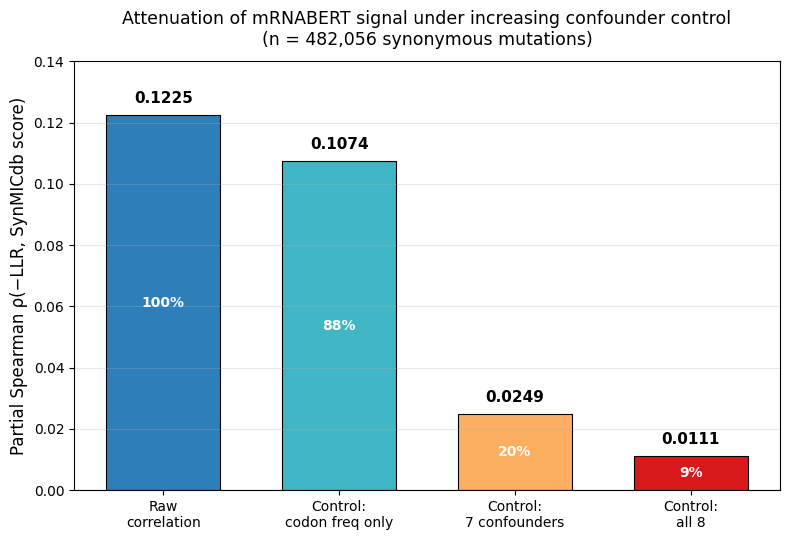

In [ ]:
import matplotlib.pyplot as plt

labels = ['Raw\ncorrelation', 'Control:\ncodon freq only',
          'Control:\n7 confounders', 'Control:\nall 8']
values = [0.1225, 0.1074, 0.0249, 0.0111]
retention = [100, 88, 20, 9]

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ['#2c7fb8', '#41b6c4', '#fdae61', '#d7191c']
bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=0.8, width=0.65)


for bar, v in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

for bar, r in zip(bars, retention):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2, f'{r}%',
            ha='center', va='center', fontsize=10, color='white', fontweight='bold')

ax.axhline(0, color='gray', linewidth=0.8)
ax.set_ylabel('Partial Spearman ρ(−LLR, SynMICdb score)', fontsize=12)
ax.set_title('Attenuation of mRNABERT signal under increasing confounder control\n'
             '(n = 482,056 synonymous mutations)', fontsize=12.5, pad=12)
ax.set_ylim(0, 0.14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_partial_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()

**What it shows:**

four bars = the correlation of −LLR with the SynMICdb score under increasing control. Left to right confounders were added -> the signal melt away. The color (blue -> red) and the percentages inside the bars emphasize the drop.
- Blue (0.1225, 100%) — the original relationship.
- Teal (0.1074, 88%) — after controlling only for codon frequency the signal barely dropped. The main visual argument: **mRNABERT does not eqaul codon frequency**
- Orange (0.0249, 20%) — controlling for the 7 "biological" confounders collapses the signal. So they explain most of it
- Red (0.0111, 9%) — after everything, almost zero remains.

"codon frequency removes almost no signal (88% remains), while the other confounders remove almost all of it, meaning mRNABERT encodes context beyond codon frequency, but this context corresponds weakly to the SynMICdb score."


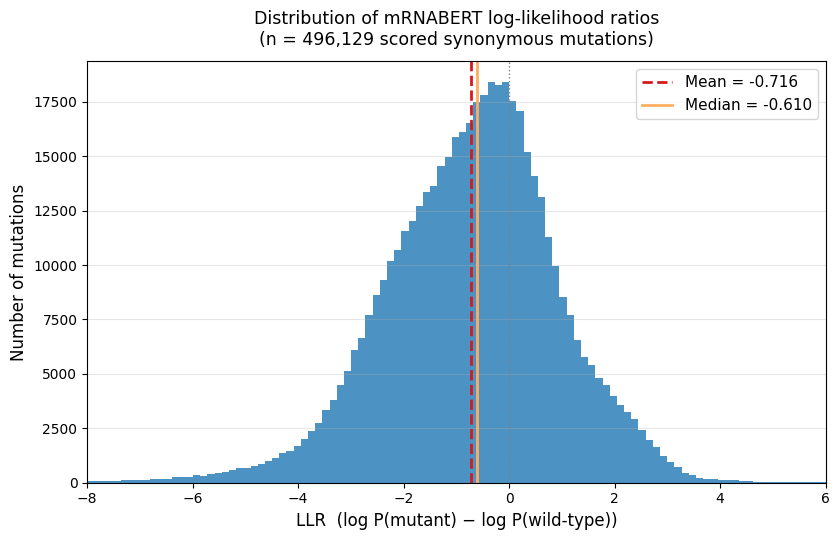

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


llr = pd.read_parquet("/content/drive/MyDrive/mrabert_run/llr_results.parquet")
v = llr["llr"].dropna()

mean_v   = v.mean()
median_v = v.median()

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(v, bins=200, color="#2c7fb8", edgecolor="none", alpha=0.85)


ax.axvline(mean_v,   color="#d7191c", linewidth=2, linestyle="--", label=f"Mean = {mean_v:.3f}")
ax.axvline(median_v, color="#fdae61", linewidth=2, linestyle="-",  label=f"Median = {median_v:.3f}")
ax.axvline(0, color="gray", linewidth=1, linestyle=":")

ax.set_xlabel("LLR  (log P(mutant) − log P(wild-type))", fontsize=12)
ax.set_ylabel("Number of mutations", fontsize=12)
ax.set_title("Distribution of mRNABERT log-likelihood ratios\n"
             "(n = 496,129 scored synonymous mutations)", fontsize=12.5, pad=12)
ax.set_xlim(-8, 6)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig2_llr_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Statistics below the plot:**

- n = 496,129, mean = −0.716, median = −0.610
- share of LLR < 0: 66.3%
- range: −16.48 … +10.76

**What it shows:**

the distribution is bell-shaped but shifted left (mean and median are negative, both lines to the left of zero). Two-thirds of all synonymous mutations get a negative LLR.

**How to interpret:**

the negative shift means that mRNABERT on average rates the mutant codon as less probable than the original. This is biologically meaningful: the model learned the "normal" codon patterns in human mRNA, and a random synonymous substitution more often leads away from the learned optimum than toward it.

**The key point** — the model doesn't produce symmetric noise around zero (which would be a sign it learned nothing); instead there's a directional signal. The left tail (strongly negative LLR) is the mutations the model considers sharply "undesirable," and it's precisely these that are candidates for functional significance, testable in Test A/B.

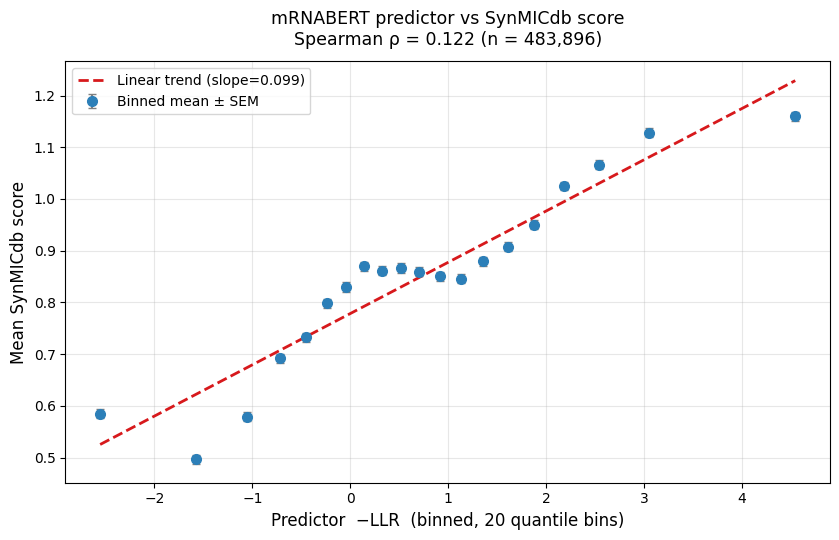

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np

d = df[df["llr"].notna() & df["has_score"]].copy()

d["bin"] = pd.qcut(d["pred"], q=20, duplicates="drop")

g = d.groupby("bin", observed=True).agg(
    pred_mean=("pred", "mean"),
    score_mean=("SynMICdb Score", "mean"),
    score_sem=("SynMICdb Score", lambda x: x.std()/np.sqrt(len(x))),
    n=("pred", "size")
).reset_index()

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.errorbar(g["pred_mean"], g["score_mean"], yerr=g["score_sem"],
            fmt="o", color="#2c7fb8", ecolor="gray", capsize=3,
            markersize=7, linewidth=1.5, label="Binned mean ± SEM")

z = np.polyfit(g["pred_mean"], g["score_mean"], 1)
xx = np.linspace(g["pred_mean"].min(), g["pred_mean"].max(), 100)
ax.plot(xx, np.polyval(z, xx), "--", color="#d7191c", linewidth=2,
        label=f"Linear trend (slope={z[0]:.3f})")

ax.set_xlabel("Predictor  −LLR  (binned, 20 quantile bins)", fontsize=12)
ax.set_ylabel("Mean SynMICdb score", fontsize=12)
ax.set_title("mRNABERT predictor vs SynMICdb score\nSpearman ρ = 0.122 (n = 483,896)",
             fontsize=12.5, pad=12)
ax.grid(alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("fig3_pred_vs_score.png", dpi=300, bbox_inches="tight")
plt.show()

**What it shows:** 20 points, each = the mean SynMICdb score for a group of mutations with similar −LLR. Left (low −LLR, model says "harmless") ->  right (high −LLR, model says "harmful").

**What's visible:** an upward trend: the higher the −LLR, the higher the mean score. The score rises from ~0.5 (left bins) to ~1.16 (right bins) — i.e. on average there is a difference and it's monotonic. This is the visualization of rho = 0.122: the relationship is real and visible, but the scatter of points around the line and a couple of "outlier" bins on the left are a reminder that the relationship is weak (if rho were 0.8, the points would lie perfectly on a straight line).

*nuance:* the far-left bins behave unstably (one at 0.50, another at 0.58, but with a dip to 0.50 between them). This is normal for a weak correlation: at the edges of the −LLR distribution there's noise. The main thing is that the overall trend is steadily upward, which confirms the directional hypothesis.

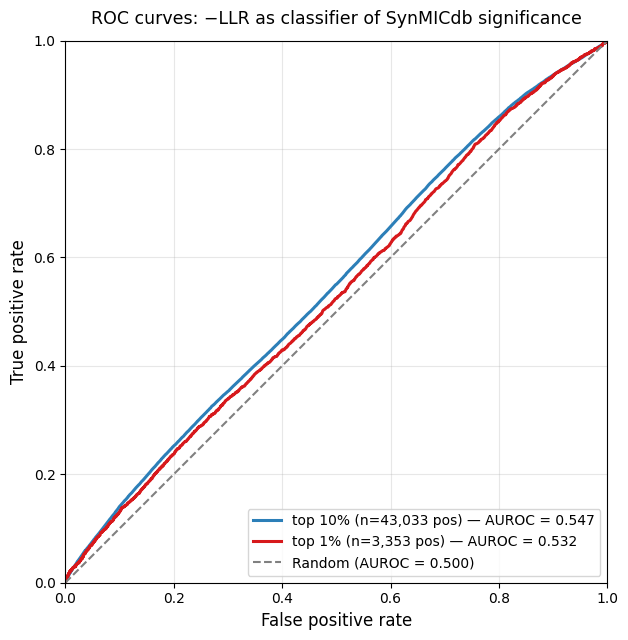

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score

d = df[df["llr"].notna() & df["has_score"]].copy()

fig, ax = plt.subplots(figsize=(6.8, 6.5))

colors = {"top10": "#2c7fb8", "top1": "#d7191c"}
names  = {"top10": "top 10% (n=43,033 pos)", "top1": "top 1% (n=3,353 pos)"}

for label in ["top10", "top1"]:
    y = d[label].astype(int)
    fpr, tpr, _ = roc_curve(y, d["pred"])
    auc = roc_auc_score(y, d["pred"])
    ax.plot(fpr, tpr, color=colors[label], linewidth=2.2,
            label=f"{names[label]} — AUROC = {auc:.3f}")

ax.plot([0,1],[0,1], "--", color="gray", linewidth=1.5, label="Random (AUROC = 0.500)")

ax.set_xlabel("False positive rate", fontsize=12)
ax.set_ylabel("True positive rate", fontsize=12)
ax.set_title("ROC curves: −LLR as classifier of SynMICdb significance", fontsize=12.5, pad=12)
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_aspect("equal")
ax.legend(fontsize=10, loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig4_roc.png", dpi=300, bbox_inches="tight")
plt.show()

**ROC curves for top10 and top1 (Test B)**

**What it shows:**
The ROC curve = how well −LLR separates significant mutations from non-significant ones across all possible thresholds. The more the curve bends toward the top-left corner, the better the classifier. The grey diagonal = random guessing.

**What's visible:** both curves (blue top10, red top1) lie slightly above the diagonal, but close to it. This is the visual portrait of AUROC 0.547 and 0.532 — barely better than a coin flip. There's a gap between the curves and the diagonal (so the signal isn't zero), but it's small.

**interpretation:**
"The ROC curves confirm the conclusion of Test B: as a binary classifier of significance, −LLR works weakly. The curves are consistently above the diagonal along their whole length (i.e. the signal is real and not random), but their closeness to the diagonal reflects low discriminative ability (AUROC 0.53–0.55). The model is suitable for weak ranking, but not for reliable classification of individual mutations."


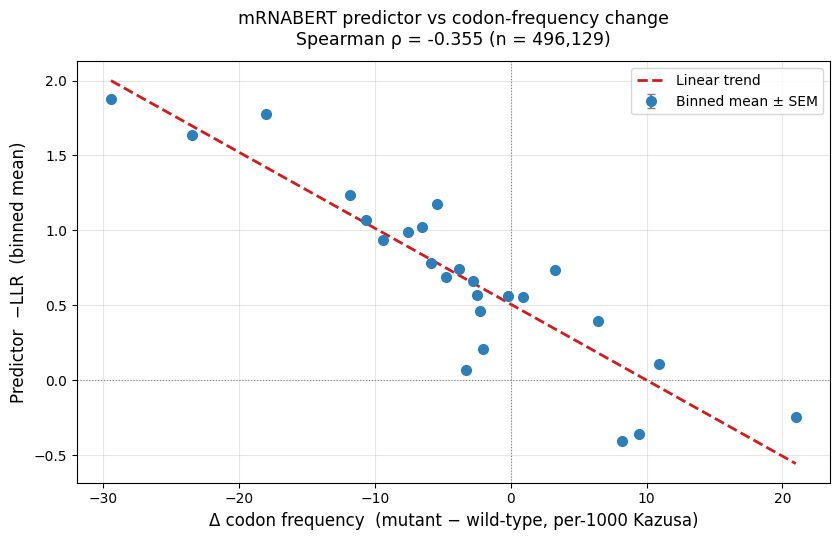

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
from scipy.stats import spearmanr

d = df[df["llr"].notna() & df["dfreq"].notna()].copy()

d["bin"] = pd.qcut(d["dfreq"], q=25, duplicates="drop")
g = d.groupby("bin", observed=True).agg(
    dfreq_mean=("dfreq", "mean"),
    pred_mean=("pred", "mean"),
    pred_sem=("pred", lambda x: x.std()/np.sqrt(len(x)))
).reset_index()

rho, _ = spearmanr(d["pred"], d["dfreq"])

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.errorbar(g["dfreq_mean"], g["pred_mean"], yerr=g["pred_sem"], fmt="o",
            color="#2c7fb8", ecolor="gray", capsize=3, markersize=7,
            linewidth=1.5, label="Binned mean ± SEM")
z = np.polyfit(g["dfreq_mean"], g["pred_mean"], 1)
xx = np.linspace(g["dfreq_mean"].min(), g["dfreq_mean"].max(), 100)
ax.plot(xx, np.polyval(z, xx), "--", color="#d7191c", linewidth=2, label="Linear trend")
ax.axvline(0, color="gray", linewidth=0.8, linestyle=":")
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")

ax.set_xlabel("Δ codon frequency  (mutant − wild-type, per-1000 Kazusa)", fontsize=12)
ax.set_ylabel("Predictor  −LLR  (binned mean)", fontsize=12)
ax.set_title(f"mRNABERT predictor vs codon-frequency change\n"
             f"Spearman ρ = {rho:.3f} (n = {len(d):,})", fontsize=12.5, pad=12)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig5_llr_vs_dfreq.png", dpi=300, bbox_inches="tight")
plt.show()

**−LLR vs Δcodon frequency**

Shows rho = −0.354: the model is moderately related to codon frequency but is NOT identical to it (this is the justification for why the codon-frequency control barely killed the signal).

**What it shows:** the relationship between the model's prediction (−LLR) and whether the mutation leads toward a more frequent or a rarer codon (Δfreq). Left: mutations into a rare codon (Δfreq < 0), right: into a frequent one (Δfreq > 0).

**What's visible:** a clear downward trend. Mutations into rare codons (left) -> high −LLR (model: "harmful"). Mutations into frequent codons (right) -> low/negative −LLR (model: "normal"). This makes sense: mRNABERT learned that frequent codons are "normal" and penalizes moving into rare ones.

**Key meaning:**

rho = −0.355 — the relationship is moderate but far from complete. If LLR were simply a function of codon frequency, the points would lie perfectly on a straight line and rho would be ~−0.9. Instead there's noticeable scatter around the trend (especially in the center, at Δfreq≈0, where −LLR ranges from 0.07 to 1.17).

This scatter = the part of the LLR signal that is NOT explained by codon frequency. It's precisely this part that survives in the partial correlation